# Imports

In [159]:
from os import listdir

import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans

%matplotlib inline

# Problem 2

In [160]:
def create_circular_edgelist(N, I):
    edge_list = []
    for u in range(N):
        for v in range(N):
            for i in I:
                if v == (u + i) % N: edge_list.append((u, v))
    return edge_list


## (a)

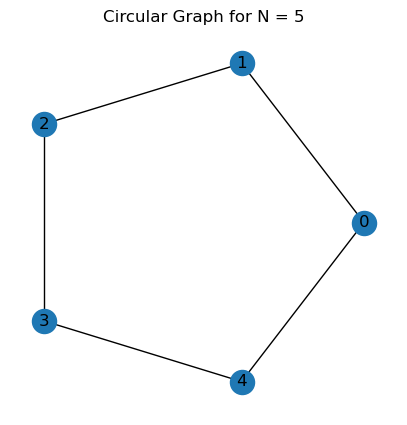

In [161]:
N = 5
I = [1]
G = nx.Graph(create_circular_edgelist(N, I))

fig = plt.figure(figsize = (5,5))
plt.title(f'Circular Graph for N = {N}')
pos = nx.circular_layout(G)
nx.draw_circular(G)
nx.draw_networkx_labels(G, pos)
plt.show()

## (b)

In [162]:
import networkx as nx
import numpy as np

N = 5
G = nx.cycle_graph(N)
L = nx.laplacian_matrix(G).toarray()

# Get your analytical eigenvalues and eigenvectors
# (Using the formula from your professor's slide)
k = np.arange(N)
lambdas_analytical = 2 * (1 - np.cos(2 * np.pi * k / N))
m = np.arange(N).reshape(-1, 1)
U_complex = (1 / np.sqrt(N)) * (np.exp(-1j * 2 * np.pi * k / N) ** m)

# VERIFICATION: Does L * u = lambda * u?
for i in range(N):
    u_i = U_complex[:, i]
    lam_i = lambdas_analytical[i]
    
    # Check the difference between L*u and lambda*u
    error = np.linalg.norm(L @ u_i - lam_i * u_i)
    print(f"Eigenvector {i} Error: {error:.2e}")

Eigenvector 0 Error: 0.00e+00
Eigenvector 1 Error: 2.17e-16
Eigenvector 2 Error: 4.87e-16
Eigenvector 3 Error: 4.30e-16
Eigenvector 4 Error: 6.50e-16


In [163]:
analytical_U_complex

array([[ 0.4472136 +0.00000000e+00j,  0.63245553+0.00000000e+00j,
         0.63245553+0.00000000e+00j,  0.        +0.00000000e+00j,
         0.        +0.00000000e+00j],
       [ 0.4472136 +0.00000000e+00j,  0.19543951+3.92523115e-17j,
        -0.51166727-7.85046229e-17j, -0.18587402+0.00000000e+00j,
        -0.30075048+0.00000000e+00j],
       [ 0.4472136 +0.00000000e+00j, -0.51166727-1.17756934e-16j,
         0.19543951+7.85046229e-17j,  0.30075048+0.00000000e+00j,
        -0.18587402+0.00000000e+00j],
       [ 0.4472136 +0.00000000e+00j, -0.51166727-1.96261557e-16j,
         0.19543951+3.92523115e-17j, -0.30075048+0.00000000e+00j,
         0.18587402+0.00000000e+00j],
       [ 0.4472136 +0.00000000e+00j,  0.19543951+7.85046229e-17j,
        -0.51166727-1.96261557e-16j,  0.18587402+0.00000000e+00j,
         0.30075048+0.00000000e+00j]])

In [164]:
# Using analytic expression prodivded in lecture
analytic_predictions = np.array([2*(1 - np.cos(2*np.pi*k/N)) for k in range(N)])
k = np.arange(N)
n = np.arange(N)
analytical_U_complex = (1 / np.sqrt(N)) * np.exp(-1j * 2*np.pi * k / N)**m
analytical_U_real = analytical_U_complex
analytical_U_real[:, 1] = (analytical_U_complex[:, 1] + analytical_U_complex[:, 4]) / np.sqrt(2)
analytical_U_real[:, 4] = (analytical_U_complex[:, 1] - analytical_U_complex[:, 4]).imag / np.sqrt(2)
analytical_U_real[:, 2] = (analytical_U_complex[:, 2] + analytical_U_complex[:, 3]) / np.sqrt(2)
analytical_U_real[:, 3] = (analytical_U_complex[:, 2] - analytical_U_complex[:, 3]).imag / np.sqrt(2)
# Numerically calculating laplacian eigenvalues
laplacian_eig = nx.laplacian_spectrum(G)[::-1]

print(f"Analytic Predictions:   {np.array2string((analytic_predictions), precision=4)}")
print(f"Analytic Eigenvectors: \n{np.array2string(analytical_U_real.real, precision=4, suppress_small=True)}")
print(f"Numerical Calculations: {np.array2string(laplacian_eig, precision=4, suppress_small=True)}")
print(f"Numerical Eigenvectors: \n{np.array2string(np.linalg.eigh(nx.laplacian_matrix(G).toarray())[1], precision = 4)}")


Analytic Predictions:   [0.    1.382 3.618 3.618 1.382]
Analytic Eigenvectors: 
[[ 0.4472  0.6325  0.6325  0.      0.    ]
 [ 0.4472  0.1954 -0.5117 -0.1859 -0.3008]
 [ 0.4472 -0.5117  0.1954  0.3008 -0.1859]
 [ 0.4472 -0.5117  0.1954 -0.3008  0.1859]
 [ 0.4472  0.1954 -0.5117  0.1859  0.3008]]
Numerical Calculations: [3.618 3.618 1.382 1.382 0.   ]
Numerical Eigenvectors: 
[[-0.4472  0.5547  0.3039 -0.2346  0.5873]
 [-0.4472  0.4604 -0.4336  0.535  -0.3373]
 [-0.4472 -0.2701 -0.5719 -0.6311 -0.0416]
 [-0.4472 -0.6274  0.0802  0.4861  0.4046]
 [-0.4472 -0.1176  0.6214 -0.1554 -0.6131]]


In [165]:
V_num = np.linalg.eigh(nx.laplacian_matrix(G).toarray())[1]
V_ana = analytical_U_real.real
print(V_num.T @ V_ana @ V_num )

[[ 0.4472136  -0.55466254 -0.30389055  0.23461462 -0.58732953]
 [-0.28476411  0.43204229 -0.52956832  0.50655951 -0.1484873 ]
 [-0.41098589  0.16965239  0.0641477   0.18892868 -0.43087695]
 [ 0.37354994  0.39149509  0.17491696  0.00840496 -0.17243256]
 [-0.3323559  -0.13447558 -0.54594136 -0.67621376 -0.11371593]]


## (c)

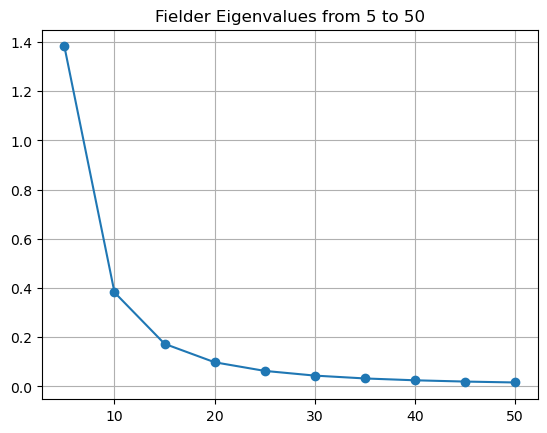

In [166]:
# Looping through N for Fielder eigenvalue
start = 5
stop = 50
step = 5
N = np.arange(start, stop+step, step)

fielder_values = [nx.algebraic_connectivity(nx.Graph(create_circular_edgelist(n, I))) for n in N]

fig = plt.figure()
plt.plot(N, fielder_values, '-o')
plt.title('Fielder Eigenvalues from 5 to 50')
plt.grid()
plt.show()

## (d)

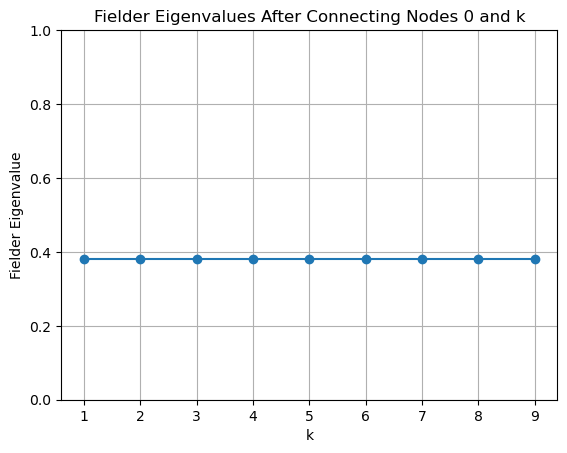

In [167]:
N = 10
G = nx.Graph(create_circular_edgelist(N, I))

fielder_eigenvalues = [None for n in range(1, N)]

for n in range(N-1):
    # Node to be connected
    u = n + 1
    # Checking to see if the edge already exists
    # If the edge exists, connectivity will not change, so fielder eigenvalue remains unchanged
    if G.has_edge(0, u):
        fielder_eigenvalues[n] = nx.algebraic_connectivity(G)
    
    # If the edge does not already exist, create it, analyze, and delete it
    else:
        G.add_edge(0, u)
        fielder_eigenvalues[n] = nx.algebraic_connectivity(G)
        G.remove_edge(0, u)
        
# Plotting results        
fig = plt.figure()
plt.plot(range(1, N), fielder_eigenvalues, '-o')
plt.title('Fielder Eigenvalues After Connecting Nodes 0 and k')
plt.xlabel('k')
plt.ylabel('Fielder Eigenvalue')
plt.grid()
plt.autoscale(False, axis = 'y')
plt.show()


# Problem 3

In [168]:
def spectral_clustering(G: nx.Graph, K: int, normalized = False):
    L = nx.normalized_laplacian_matrix(G).toarray() if normalized else nx.laplacian_matrix(G).toarray()
    
    # Using eigh because L is supposed to be symmetric
    eigvals, eigvecs = np.linalg.eigh(L)
    
    # Using K-means on rows of K_least_vectors
    U = eigvecs[:, :K]
    
    if normalized:
        U = U / np.linalg.norm(U, axis=1, keepdims=True)
    
    K_means = KMeans(n_clusters = K)
    labels = K_means.fit_predict(U)
    
    return labels

In [169]:
karate_graph = nx.karate_club_graph()
pos = nx.circular_layout(karate_graph)

## (a)

c:\Users\djd14\miniconda3\envs\eel6878\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


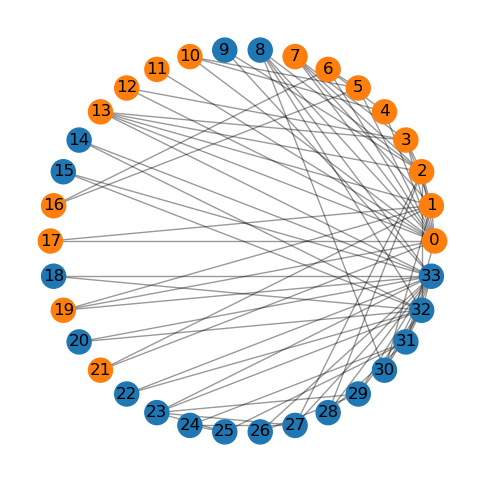

In [158]:
K = 2    
labels = spectral_clustering(karate_graph, K)

colors = ['tab:blue' if label == 0 else 'tab:orange' for label in labels]

fig = plt.figure(figsize = (6,6))
nx.draw_networkx_nodes(karate_graph, pos, node_color = colors)
nx.draw_networkx_labels(karate_graph, pos)
nx.draw_networkx_edges(karate_graph, pos, alpha = 0.4)
plt.axis('off')
plt.show()

## (b)

c:\Users\djd14\miniconda3\envs\eel6878\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


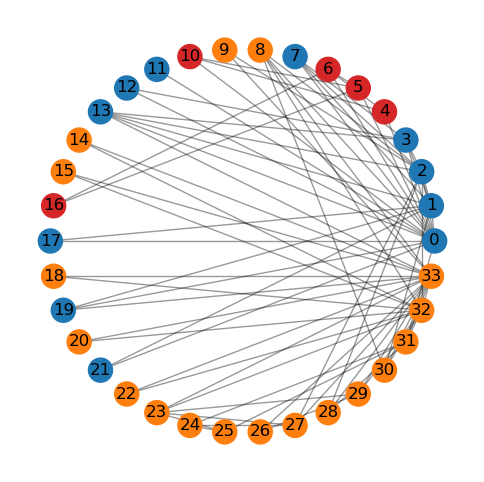

In [10]:
K = 3
labels = spectral_clustering(karate_graph, K)
colors = ['tab:blue' if label == 0 else 'tab:orange' if label == 1 else 'tab:red' for label in labels]

fig = plt.figure(figsize = (6,6))
nx.draw_networkx_nodes(karate_graph, pos, node_color = colors)
nx.draw_networkx_labels(karate_graph, pos)
nx.draw_networkx_edges(karate_graph, pos, alpha = 0.4)
plt.axis('off')
plt.show()

# Problem 4

In [172]:
chars = pd.read_csv("HW2_2026_Harry_Potter_Graph/characters.csv")
edges = pd.read_csv("HW2_2026_Harry_Potter_Graph/relations.csv")

G = nx.Graph()
for _, row in edges.iterrows():
    G.add_edge(row['source'], row['target'], weight = row['weight'], type = row['type'])

In [176]:
node_count = G.number_of_nodes()
edge_count = G.number_of_edges()
average_degree = 2 * edge_count / node_count
density = nx.density(G)
is_connected = nx.is_connected(G)
connected_components = nx.number_connected_components(G)
print(f"Node Count: {node_count}")
print(f"Edge Count: {edge_count}")
print(f"Average Degree: {average_degree:0.4f}")
print(f"Density = {density:0.4f}")
print(f"Is Graph Connected: {is_connected}")
print(f"Connected Components: {connected_components}")
print(f"Algeraic Connectivity: {nx.algebraic_connectivity(G):0.4f}")
friend_edge_count = 0
foe_edge_count = 0

for (u, v, d) in G.edges(data = True):
    if d['type'] == '-': 
        foe_edge_count += 1
        
    elif d['type'] == '+': 
        friend_edge_count += 1
        
print(f"Ally Edge Count: {friend_edge_count}")
print(f"Enemy Edge Count: {foe_edge_count}")

Node Count: 65
Edge Count: 317
Average Degree: 9.7538
Density = 0.1524
Is Graph Connected: True
Connected Components: 1
Algeraic Connectivity: 0.8040
Ally Edge Count: 211
Enemy Edge Count: 106


# Problem 5

## (a)

Calculating centralities for each node and storing as dicts for consistency

In [13]:
degree_centrality = dict(G.degree())
weighted_degree_centrality = dict(G.degree(weight = 'weight'))
betweeness_centrality = nx.betweenness_centrality(G)
closeness_centrality = nx.closeness_centrality(G)
eigenvector_centrality = nx.eigenvector_centrality(G)
pagerank = nx.pagerank(G, weight = None)

Putting centrality calculations in a pandas dataframe

In [14]:
centrality = chars.copy()
# Putting centralities in a dataframe so they area bit easier to view
centrality['Degree']            = centrality['id'].map(degree_centrality)
centrality['Weighted Degree']   = centrality['id'].map(weighted_degree_centrality)
centrality['Betweeness']        = centrality['id'].map(betweeness_centrality)
centrality['Closeness']         = centrality['id'].map(closeness_centrality)
centrality['Eigenvector']       = centrality['id'].map(eigenvector_centrality)
centrality['Pagerank']          = centrality['id'].map(pagerank)

## (b)

Displaying Top 10 of each centrality

In [15]:
# List of centrality types (Keeping your spelling for consistency)
centrality_types = ['Degree', 'Weighted Degree', 'Betweeness', 'Closeness', 'Eigenvector', 'Pagerank']

# Create an empty dictionary to store the top 10 names for each measure
top_10_dict = {}

for centrality in centrality_types:
    # Get the names of the top 10 for each centrality type
    top_10_dict[centrality] = centrality.nlargest(10, centrality)['name'].values

# Create the final summary DataFrame
summary_df = pd.DataFrame(top_10_dict)
summary_df.index = range(1, 11)  # Set index to start from 1
summary_df.index.name = 'Rank'

# Generate the LaTeX code
print(summary_df.to_latex(
    index=True, 
    caption="Top 10 Nodes by Centrality Measure", 
    label="tab:centrality_top10",
    columns = ['Degree', 'Weighted Degree', 'Betweeness'],
    column_format='l' + 'c' * len(centrality_types[:3]) # Left align rank, center others
))

print(summary_df.to_latex(
    index=True, 
    caption="Top 10 Nodes by Centrality Measure", 
    label="tab:centrality_top10",
    columns = ['Closeness', 'Eigenvector', 'Pagerank'],
    column_format='l' + 'c' * len(centrality_types[:3]) # Left align rank, center others
))


AttributeError: 'str' object has no attribute 'nlargest'

# Problem 6

## (a)

Creating Communities

In [ ]:
# Finds communities
communities = nx.community.louvain_communities(G, weight = 'weight', seed = 2026)

# Orders communities from largest to smallest
communities = sorted(communities, key = lambda x: len(x), reverse=True)

Drawing Plot

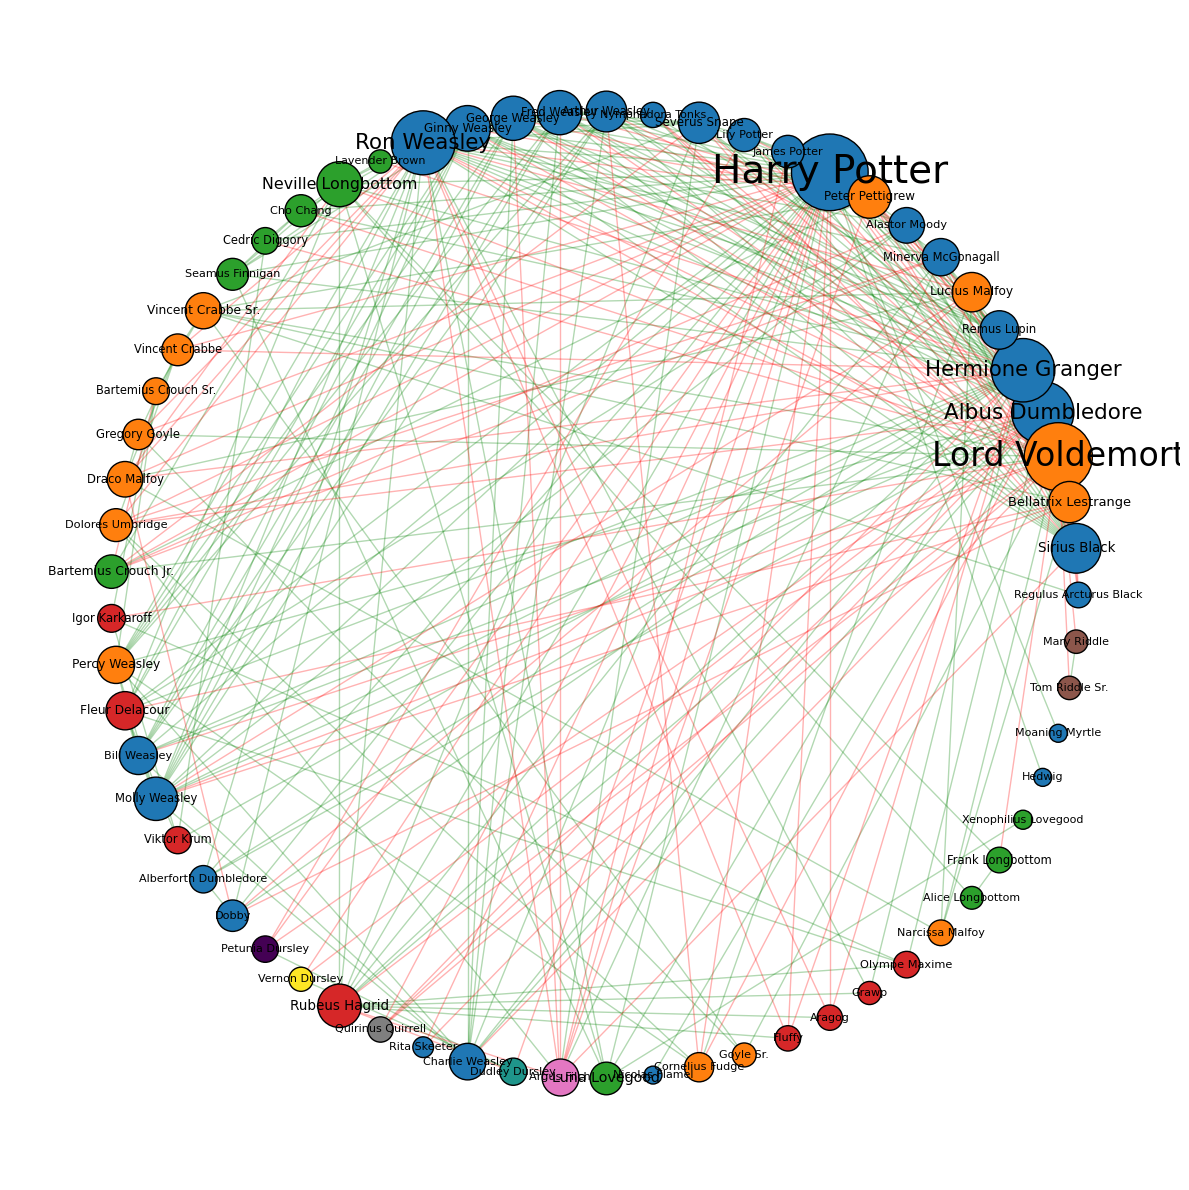

In [ ]:

pos = nx.circular_layout(G)
colors = plt.cm.tab10.colors[:9]
fig = plt.figure(figsize = (12, 12))
for nodes, color in zip(communities, colors):
    node_size = centrality.loc[list(nodes), 'Pagerank']/max(centrality['Pagerank'])**4 + 10
    nx.draw_networkx_nodes(G, pos = pos, nodelist = nodes, node_color=color, edgecolors='k', node_size = node_size )

labels = dict(zip(chars['id'], chars['name']))
label_size = dict(zip(centrality['id'], 20*centrality['Betweeness']/max(centrality['Betweeness']) + 8))
nx.draw_networkx_labels(G, pos, labels = labels, font_size = label_size)

# Drawing edges green/red based on friend/foe
friend_edges = []
foe_edges = []

for u, v, d in G.edges(data = True):
    if d['weight'] < 0:
        foe_edges.append((u, v))
    elif d['weight'] > 0:
        friend_edges.append((u,v))
        
nx.draw_networkx_edges(G, pos, edgelist = friend_edges, edge_color= 'green', alpha = 0.3)
nx.draw_networkx_edges(G, pos, edgelist = foe_edges, edge_color= 'red', alpha = 0.3)

plt.tight_layout()
plt.axis('off')
plt.show()